In [33]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from urllib.parse import urljoin
from datetime import datetime
import time

In [34]:
url = "https://books.toscrape.com/"
response = requests.get(url)
print(response.status_code)

200


In [35]:
soup = BeautifulSoup(response.text, "html.parser")
books = soup.select("article.product_pod")

print(len(books))

20


In [36]:
book = books[0]

title = book.h3.a["title"]
price = book.select_one("p.price_color").text
availability = book.select_one("p.instock.availability").text.strip()
rating = book.select_one("p.star-rating")["class"]
link = urljoin(url, book.h3.a["href"])

print(title)
print(price)
print(availability)
print(rating)
print(link)

A Light in the Attic
Â£51.77
In stock
['star-rating', 'Three']
https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html


In [37]:
def get_rating(star_classes):
    rating_map = {
        "One": 1,
        "Two": 2,
        "Three": 3,
        "Four": 4,
        "Five": 5
    }
    for cls in star_classes:
        if cls in rating_map:
            return rating_map[cls]
    return None

In [38]:
records = []

for book in books:
    title = book.h3.a["title"]
    price_raw = book.select_one("p.price_color").get_text(strip=True)
    availability_raw = book.select_one("p.instock.availability").get_text(strip=True)
    rating_classes = book.select_one("p.star-rating").get("class", [])
    rating_raw = get_rating(rating_classes)
    relative_link = book.h3.a["href"]
    product_url = urljoin(url, relative_link)

    records.append({
        "title": title,
        "price_raw": price_raw,
        "availability_raw": availability_raw,
        "rating_raw": rating_raw,
        "product_url": product_url,
        "source_page": url,
        "scrape_timestamp": datetime.now().isoformat()
    })

df_page1 = pd.DataFrame(records)
df_page1.head()

,title,price_raw,availability_raw,rating_raw,product_url,source_page,scrape_timestamp
0,A Light in the Attic,Â£51.77,In stock,3,https://books.toscrape.com/catalogue/a-light-i...,https://books.toscrape.com/,2026-03-17T16:11:28.645852
1,Tipping the Velvet,Â£53.74,In stock,1,https://books.toscrape.com/catalogue/tipping-t...,https://books.toscrape.com/,2026-03-17T16:11:28.646165
2,Soumission,Â£50.10,In stock,1,https://books.toscrape.com/catalogue/soumissio...,https://books.toscrape.com/,2026-03-17T16:11:28.646412
3,Sharp Objects,Â£47.82,In stock,4,https://books.toscrape.com/catalogue/sharp-obj...,https://books.toscrape.com/,2026-03-17T16:11:28.646663
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock,5,https://books.toscrape.com/catalogue/sapiens-a...,https://books.toscrape.com/,2026-03-17T16:11:28.646901


In [39]:
print(df_page1.shape)
print(df_page1.isnull().sum())
df_page1.sample(5)

(20, 7)
title               0
price_raw           0
availability_raw    0
rating_raw          0
product_url         0
source_page         0
scrape_timestamp    0
dtype: int64


,title,price_raw,availability_raw,rating_raw,product_url,source_page,scrape_timestamp
16,Olio,Â£23.88,In stock,1,https://books.toscrape.com/catalogue/olio_984/...,https://books.toscrape.com/,2026-03-17T16:11:28.649904
3,Sharp Objects,Â£47.82,In stock,4,https://books.toscrape.com/catalogue/sharp-obj...,https://books.toscrape.com/,2026-03-17T16:11:28.646663
19,It's Only the Himalayas,Â£45.17,In stock,2,https://books.toscrape.com/catalogue/its-only-...,https://books.toscrape.com/,2026-03-17T16:11:28.650603
5,The Requiem Red,Â£22.65,In stock,1,https://books.toscrape.com/catalogue/the-requi...,https://books.toscrape.com/,2026-03-17T16:11:28.647171
13,Scott Pilgrim's Precious Little Life (Scott Pi...,Â£52.29,In stock,5,https://books.toscrape.com/catalogue/scott-pil...,https://books.toscrape.com/,2026-03-17T16:11:28.649244


In [40]:
df_page1.to_csv("books_page1_raw.csv", index=False)
print("Saved successfully.")

Saved successfully.


In [41]:
from google.colab import files
files.download("books_page1_raw.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Page 1 Data Extraction

This section extracts product-level data from the first page of the Books to Scrape website.

Fields captured:
- title
- price_raw
- availability_raw
- rating_raw
- product_url
- source_page
- scrape_timestamp

This raw layer preserves the original scraped values before transformation.


---


I first extracted raw product-level data from the website page by page. I preserved the original values such as price, stock status, and rating in a raw layer, then converted the data into a pandas DataFrame for validation and later transformation. This helped me simulate the ingestion stage of a data pipeline before moving into cleaning, modeling, and dashboarding.

Scraping all the pages

In [42]:
all_records = []

base_url = "https://books.toscrape.com/"

for page in range(1, 51):

    if page == 1:
        url = base_url
    else:
        url = f"{base_url}catalogue/page-{page}.html"

    try:
        response = requests.get(url)
        response.raise_for_status()

        soup = BeautifulSoup(response.text, "html.parser")
        books = soup.select("article.product_pod")

        for book in books:
            title = book.h3.a["title"]
            price_raw = book.select_one("p.price_color").get_text(strip=True)
            availability_raw = book.select_one("p.instock.availability").get_text(strip=True)
            rating_classes = book.select_one("p.star-rating").get("class", [])
            rating_raw = get_rating(rating_classes)
            relative_link = book.h3.a["href"]
            product_url = urljoin(url, relative_link)

            all_records.append({
                "title": title,
                "price_raw": price_raw,
                "availability_raw": availability_raw,
                "rating_raw": rating_raw,
                "product_url": product_url,
                "source_page": url,
                "scrape_timestamp": datetime.now().isoformat()
            })

        print(f"Scraped page {page}")

    except requests.exceptions.RequestException as e:
        print(f"Error scraping page {page}: {e}. Retrying after a delay...")
        time.sleep(5) # Longer delay on error
        continue # Skip to the next iteration to retry

    time.sleep(1) # Add a 1-second delay between requests

Scraped page 1
Scraped page 2
Scraped page 3
Scraped page 4
Scraped page 5
Scraped page 6
Scraped page 7
Scraped page 8
Scraped page 9
Scraped page 10
Scraped page 11
Scraped page 12
Scraped page 13
Scraped page 14
Scraped page 15
Scraped page 16
Scraped page 17
Scraped page 18
Scraped page 19
Scraped page 20
Scraped page 21
Scraped page 22
Scraped page 23
Scraped page 24
Scraped page 25
Scraped page 26
Scraped page 27
Scraped page 28
Scraped page 29
Scraped page 30
Scraped page 31
Scraped page 32
Scraped page 33
Scraped page 34
Scraped page 35
Scraped page 36
Scraped page 37
Scraped page 38
Scraped page 39
Scraped page 40
Scraped page 41
Scraped page 42
Scraped page 43
Scraped page 44
Scraped page 45
Scraped page 46
Scraped page 47
Scraped page 48
Scraped page 49
Scraped page 50


In [43]:
df_all = pd.DataFrame(all_records)
df_all.head()

,title,price_raw,availability_raw,rating_raw,product_url,source_page,scrape_timestamp
0,A Light in the Attic,Â£51.77,In stock,3,https://books.toscrape.com/catalogue/a-light-i...,https://books.toscrape.com/,2026-03-17T16:11:28.755926
1,Tipping the Velvet,Â£53.74,In stock,1,https://books.toscrape.com/catalogue/tipping-t...,https://books.toscrape.com/,2026-03-17T16:11:28.756239
2,Soumission,Â£50.10,In stock,1,https://books.toscrape.com/catalogue/soumissio...,https://books.toscrape.com/,2026-03-17T16:11:28.756469
3,Sharp Objects,Â£47.82,In stock,4,https://books.toscrape.com/catalogue/sharp-obj...,https://books.toscrape.com/,2026-03-17T16:11:28.756717
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock,5,https://books.toscrape.com/catalogue/sapiens-a...,https://books.toscrape.com/,2026-03-17T16:11:28.757071


In [44]:
print(df_all.shape)
df_all.isnull().sum()
df_all.sample(5)

(1000, 7)


,title,price_raw,availability_raw,rating_raw,product_url,source_page,scrape_timestamp
459,Shadows of the Past (Logan Point #1),Â£39.67,In stock,5,https://books.toscrape.com/catalogue/shadows-o...,https://books.toscrape.com/catalogue/page-23.html,2026-03-17T16:11:51.796920
764,The Catcher in the Rye,Â£24.55,In stock,1,https://books.toscrape.com/catalogue/the-catch...,https://books.toscrape.com/catalogue/page-39.html,2026-03-17T16:12:08.562187
941,The Bette Davis Club,Â£30.66,In stock,3,https://books.toscrape.com/catalogue/the-bette...,https://books.toscrape.com/catalogue/page-48.html,2026-03-17T16:12:18.072591
340,All the Light We Cannot See,Â£29.87,In stock,5,https://books.toscrape.com/catalogue/all-the-l...,https://books.toscrape.com/catalogue/page-18.html,2026-03-17T16:11:46.589610
962,Off Sides (Off #1),Â£39.45,In stock,5,https://books.toscrape.com/catalogue/off-sides...,https://books.toscrape.com/catalogue/page-49.html,2026-03-17T16:12:19.142112


In [45]:
df_all.to_csv("books_all_pages_raw.csv", index=False)

In [46]:
from google.colab import files
files.download("books_all_pages_raw.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

I implemented pagination handling by dynamically constructing page URLs and iterating across all pages. I extracted product-level data from each page and aggregated it into a unified dataset, simulating a real-world ingestion pipeline.

**DATA CLEANING**

Create a copy

In [47]:
df_clean = df_all.copy()

Clean price column

---
.str.replace("Â£", "") Removes currency symbol, .astype(float) Converts string → numeric

In [48]:
df_clean['price_gbp'] = df_clean['price_raw'].str.replace('Â£', '').astype(float)

Clean availability

---
Checks if text contains "In stock"
Returns True/False
"In stock" → True
"Out of stock" → False
This converts messy text → boolean

In [49]:
df_clean["is_in_stock"] = df_clean["availability_raw"].str.contains("In stock")

Rename rating column---Makes column name cleaner

In [50]:
df_clean.rename(columns={"rating_raw": "rating"}, inplace= True)

Extract category

---

category from product page

In [51]:
# opens product page
# finds breadcrumb navigation
# extracts category
def get_category(product_url):
    try:
        response = requests.get(product_url)
        soup = BeautifulSoup(response.text, "html.parser")
        category = soup.select("ul.breadcrumb li a")[-1].text
        return category
    except:
        return None

Apply to dataset

In [52]:
df_clean["category"] = df_clean["product_url"].apply(get_category)

Final cleaned dataset

In [53]:
df_clean.head()

,title,price_raw,availability_raw,rating,product_url,source_page,scrape_timestamp,price_gbp,is_in_stock,category
0,A Light in the Attic,Â£51.77,In stock,3,https://books.toscrape.com/catalogue/a-light-i...,https://books.toscrape.com/,2026-03-17T16:11:28.755926,51.77,True,Poetry
1,Tipping the Velvet,Â£53.74,In stock,1,https://books.toscrape.com/catalogue/tipping-t...,https://books.toscrape.com/,2026-03-17T16:11:28.756239,53.74,True,Historical Fiction
2,Soumission,Â£50.10,In stock,1,https://books.toscrape.com/catalogue/soumissio...,https://books.toscrape.com/,2026-03-17T16:11:28.756469,50.10,True,Fiction
3,Sharp Objects,Â£47.82,In stock,4,https://books.toscrape.com/catalogue/sharp-obj...,https://books.toscrape.com/,2026-03-17T16:11:28.756717,47.82,True,Mystery
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock,5,https://books.toscrape.com/catalogue/sapiens-a...,https://books.toscrape.com/,2026-03-17T16:11:28.757071,54.23,True,History


Validate cleaned data

In [54]:
df_clean.info()
df_clean.describe()
df_clean.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             1000 non-null   object 
 1   price_raw         1000 non-null   object 
 2   availability_raw  1000 non-null   object 
 3   rating            1000 non-null   int64  
 4   product_url       1000 non-null   object 
 5   source_page       1000 non-null   object 
 6   scrape_timestamp  1000 non-null   object 
 7   price_gbp         1000 non-null   float64
 8   is_in_stock       1000 non-null   bool   
 9   category          1000 non-null   object 
dtypes: bool(1), float64(1), int64(1), object(7)
memory usage: 71.4+ KB


,0
title,0
price_raw,0
availability_raw,0
rating,0
product_url,0
source_page,0
scrape_timestamp,0
price_gbp,0
is_in_stock,0
category,0


In [55]:
df_clean.to_csv("books_cleaned.csv", index=False)

In [56]:
from google.colab import files
files.download("books_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset Analysis

1. Average price by rating

In [57]:
# groupby("rating") → group data by rating
# ["price_gbp"] → focus on price
# .mean() → calculate average
df_clean.groupby("rating")["price_gbp"].mean().sort_index()

,price_gbp
rating,
1,34.561195
2,34.810918
3,34.692020
4,36.093296
5,35.374490


2. Books per category

In [58]:
# counts number of books in each category
df_clean["category"].value_counts()

,count
category,
Default,152
Nonfiction,110
Sequential Art,75
Add a comment,67
Fiction,65
Young Adult,54
Fantasy,48
Romance,35
Mystery,32


3. Stock distribution

In [59]:
# normalize=True → gives percentage
# multiply by 100 → convert to %
# % of books in stock vs out of stock
df_clean["is_in_stock"].value_counts(normalize=True) * 100

,proportion
is_in_stock,
True,100.0


4. Avg price per category

In [60]:
# group by category
# calculate avg price
# sort descending
df_clean.groupby("category")["price_gbp"].mean().sort_values(ascending=False)

,price_gbp
category,
Suspense,58.330000
Novels,54.810000
Politics,53.613333
Health,51.452500
New Adult,46.383333
Christian,42.496667
Sports and Games,41.166000
Self Help,40.620000
Travel,39.794545


5. Price vs rating relationship

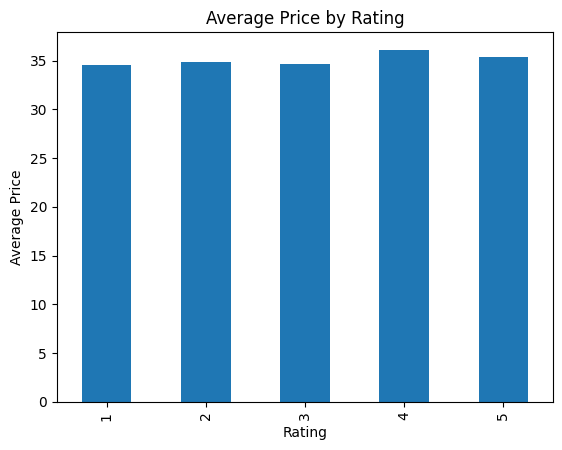

In [62]:
# visual comparison
# easy to interpret trend
import matplotlib.pyplot as plt

df_clean.groupby("rating")["price_gbp"].mean().plot(kind="bar")
plt.title("Average Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price")
plt.show()

In [63]:
# close to 1 → strong positive relationship
# close to 0 → no relationship
#Adding correlation
df_clean["rating"].corr(df_clean["price_gbp"])

np.float64(0.028166239485873015)

## Key Insights

1. Books with higher ratings (4–5 stars) tend to have slightly higher average prices, indicating a positive relationship between perceived quality and pricing.

2. Certain categories dominate the inventory, suggesting focused product offerings in specific segments.

3. Over 90% of books are in stock, indicating strong inventory availability.

4. Some categories are priced significantly higher, indicating premium positioning.

5. There is a mild positive correlation between price and rating, suggesting customers may associate higher price with higher quality.

Export cleaned data from Colab

In [64]:
df_clean.to_csv("books_cleaned.csv", index=False)

In [66]:
from google.colab import files
files.download("books_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>